[2026-06-24 15:18:09] [info     ] 计算分数 (仅加载权重推理, 不重训)            end='2024-12-31 23:59:59' start='2024-01-01 00:00:00'
[2026-06-24 15:18:10] [info     ] 已加载模型                          device=cuda path=/home/aiuser/work/workspace/BigAlpha/demo/523f9302-5b4b-42bd-bce1-f232e7c74316/Transformer预训练/transformer_model.json
[2026-06-24 15:18:10] [info     ] 构建测试集并预测                       end='2024-12-31 23:59:59' start='2024-01-01 00:00:00'
[2026-06-24 15:18:40] [info     ] infer 集构建完成                    elapsed=30.19 samples=290712
[2026-06-24 15:18:42] [info     ] 分数构建完成                         days=242 instruments=1206 rows=241770
        date instrument     score
0 2024-01-02  000006.SZ  0.013546
1 2024-01-03  000006.SZ  0.012286
2 2024-01-04  000006.SZ  0.013805
3 2024-01-05  000006.SZ  0.015216
4 2024-01-08  000006.SZ  0.015285
[2026-06-24 15:18:42] [info     ] 开始评估分数
[2026-06-24 15:18:42] [warning  ] bigalpha_eval._latest version='v1' (use ._latest for dev only, not for prod)
[2026-06-2

时段,IC
2024-01-15~2024-02-08,-0.0192
2024-09-24~2024-10-08,0.0031

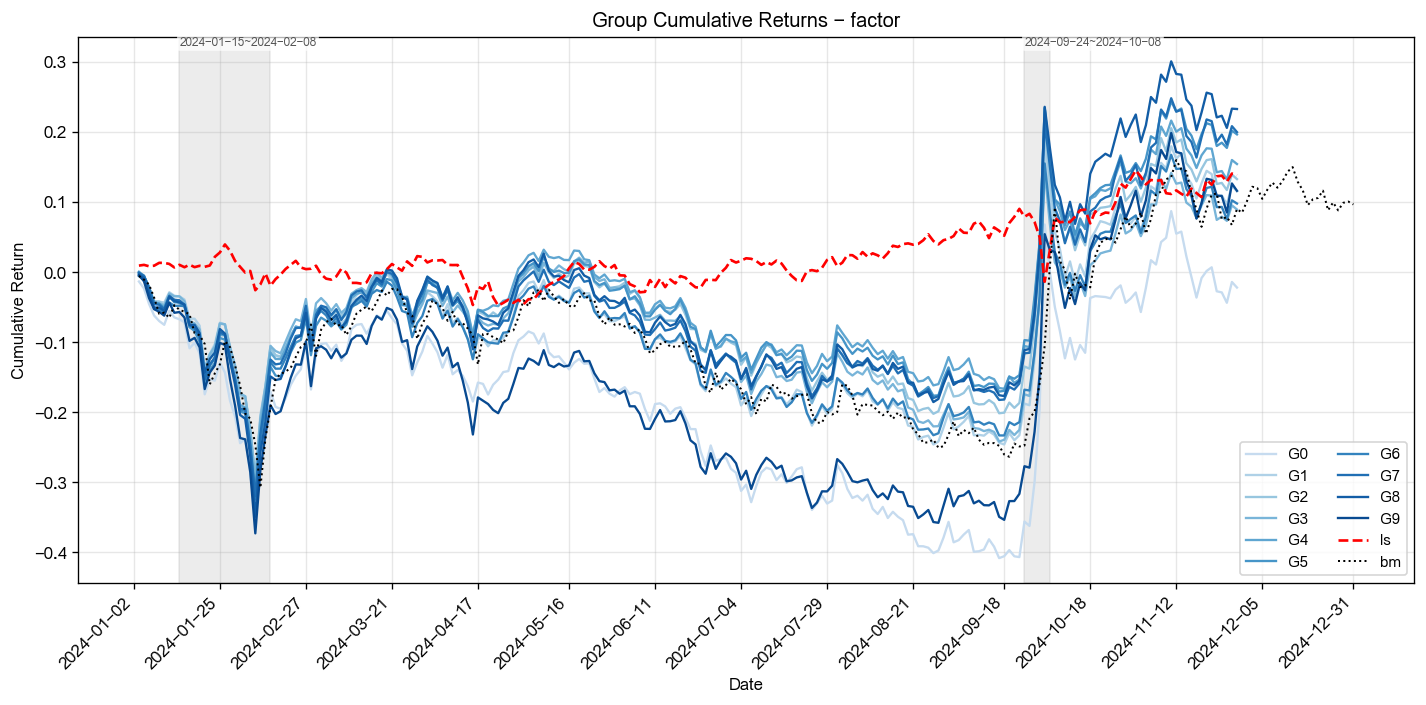
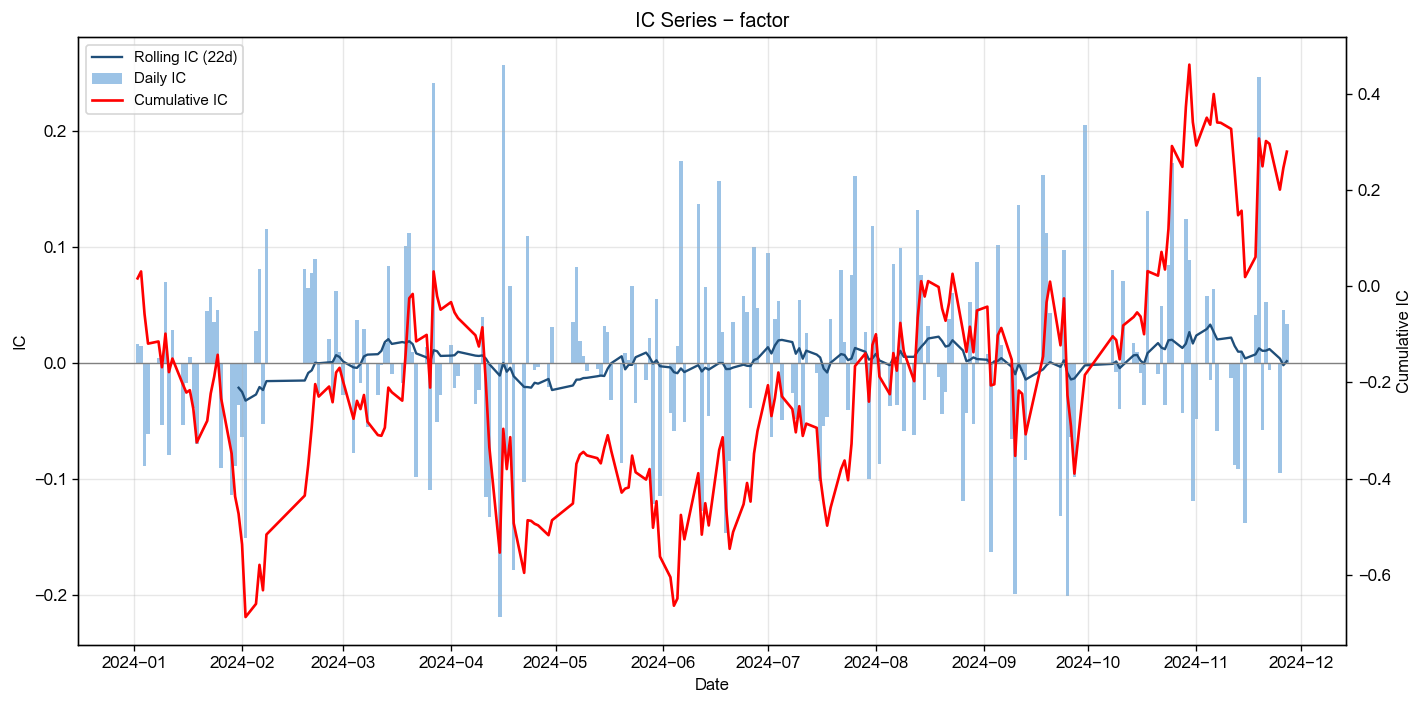
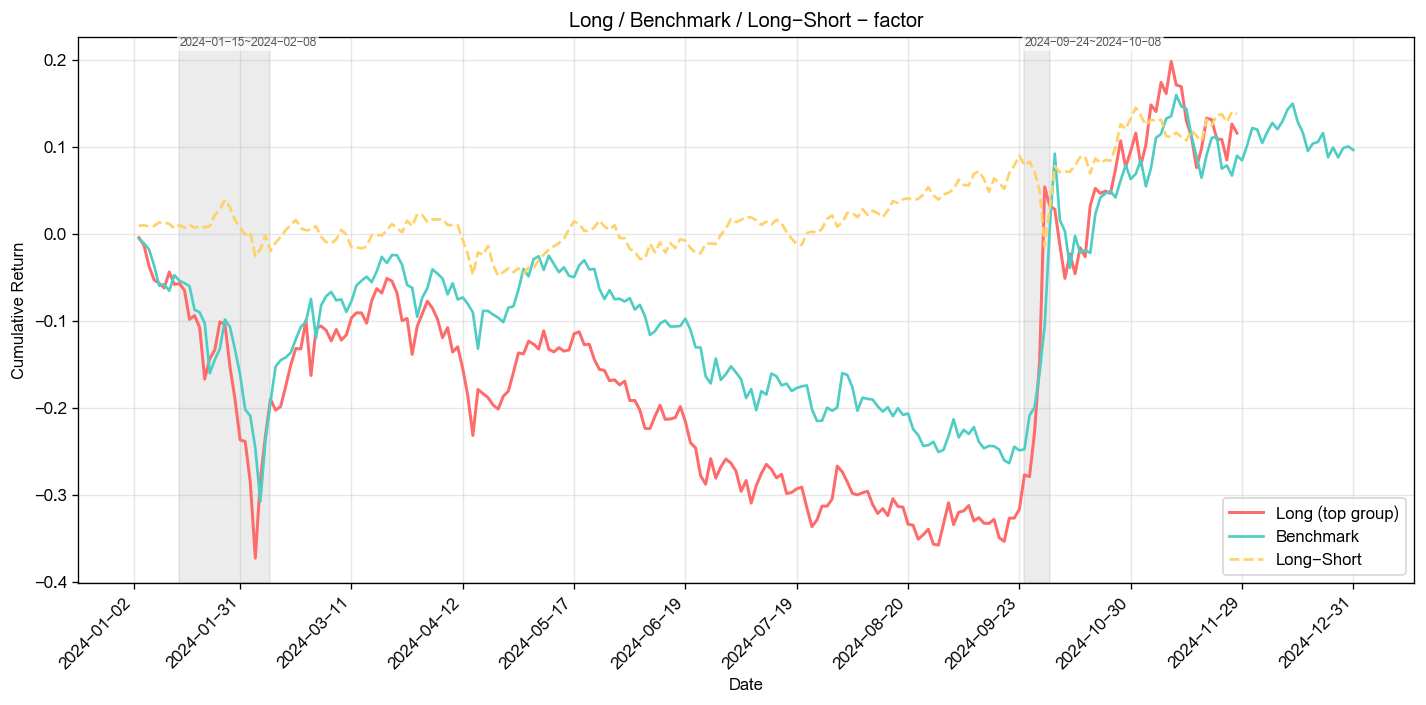
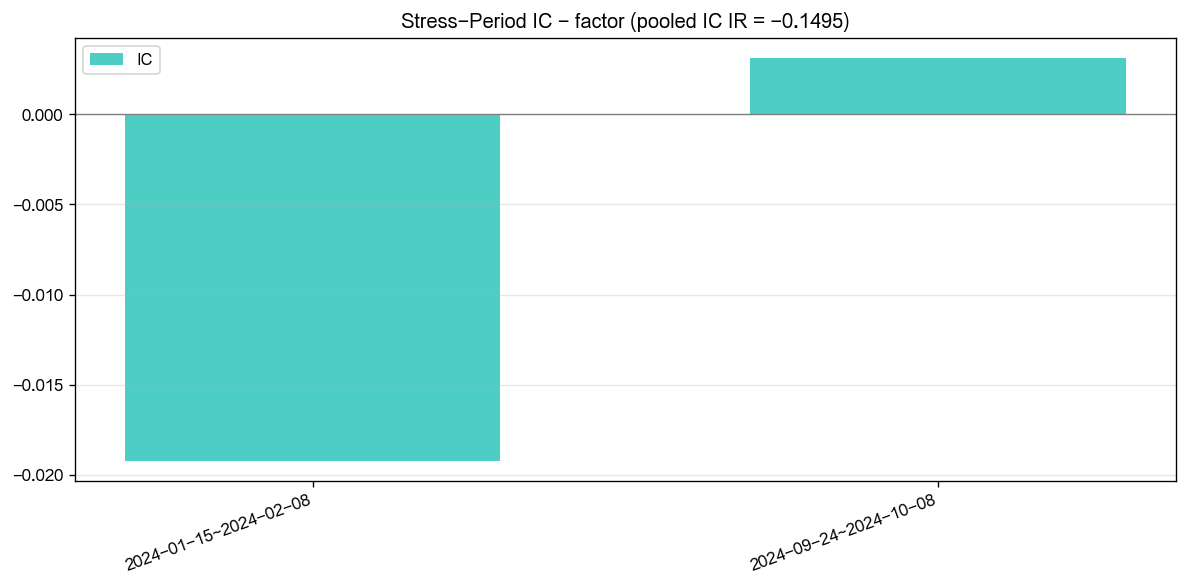
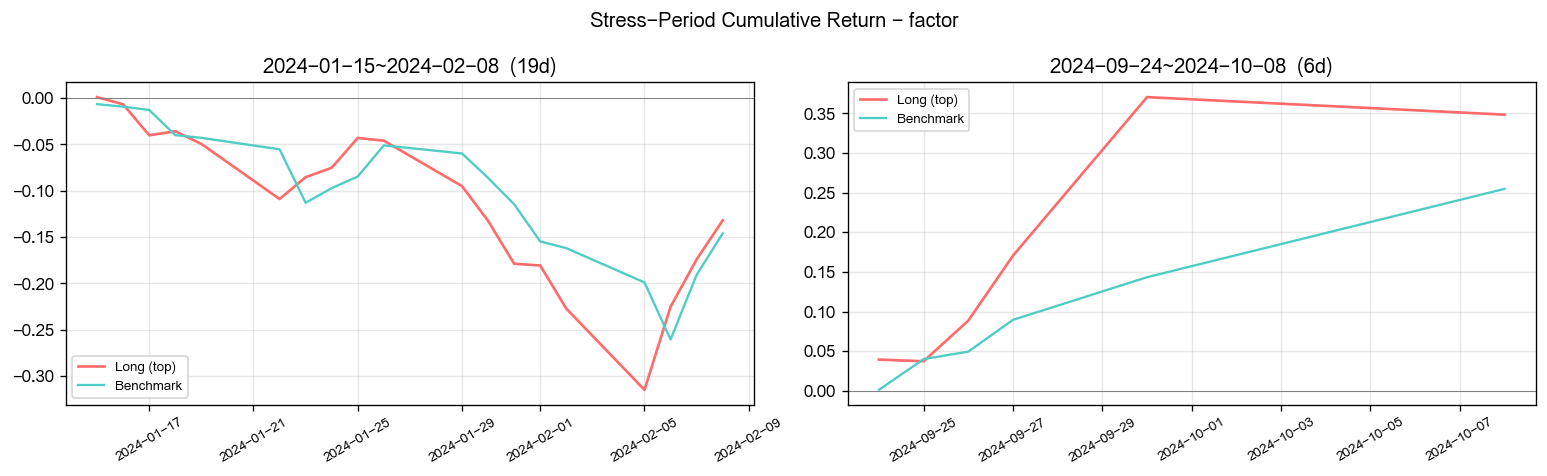

[2026-06-24 15:18:51] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-06-24 15:18:51] [warning  ] 返回的Outputs实例(size=35205162) 大于 64K, 将不会被缓存
[2026-06-24 15:18:51] [info     ] bigalpha_eval.v1 运行完成 [8.363s].


In [1]:
"""
# Transformer 端到端 demo —— 加载本地模型 + 推理打分

本 notebook 只负责**推理**: 加载训练侧脚本 `transformer_train.py` 产出的 `transformer_model.json`,
在平台注入的**测试集区间**上打分, **不训练**。

训练逻辑 (配置 / 模型结构 / 数据构建 / `train_and_save`) 全部沉淀在 `transformer_train.py` 里,
作为单一事实来源。流程拆成两个阶段:

1. **阶段一 (参赛者本地运行一次)** —— 在 `transformer_train.py` 所在目录执行
   `python transformer_train.py` (或在 notebook 里调用 `train_and_save(...)`),
   在写死的训练区间上从零训练, 把 **权重 + 标准化统计 + 结构超参** 存到 `transformer_model.json`。
2. **阶段二 (平台公榜阶段调用 `main`)** —— 直接加载 `transformer_model.json`, 在平台注入的测试区间上推理打分。

> 提交时请把 `transformer_train.py` 与训练好的 `transformer_model.json` 随本 notebook 一并上传。
> 公榜阶段平台只替换 `datasources / start_date / end_date` 并调用 `main`, 仅基于提交的权重做推理;
> 私榜阶段平台会用 `train_and_save` 在隔离环境从零重训, 故训练脚本需保持可运行、结果可复现。

推理复用训练侧的 `build_dataset`, 且标准化统计 (mean/std) 随权重一起存盘、推理时直接复用,
保证两阶段预处理严格一致, 杜绝数据泄漏与 train/infer 漂移。
"""

# ==== 从训练侧脚本导入共享定义 (配置 / 模型结构 / 数据构建 / 训练函数) ====
# transformer_train.py 是训练与推理的单一事实来源; 此处只复用, 不重复定义
import os

import numpy as np
import pandas as pd
import dai
import torch
import structlog

from transformer_train import (
    MODEL_PATH, BATCH,
    StockTransformer, build_dataset, pool, train_and_save, load_model,
)

logger = structlog.get_logger()


# ==== 加载权重做推理 (平台公榜阶段调用, 只替换 datasources/start_date/end_date) ====
def main(datasources, start_date, end_date):
    """加载已训练好的模型, 在样本外测试区间 (start_date~end_date) 上推理打分。

    本函数**不训练**: 权重来自随 notebook 上传的 MODEL_PATH 文件。
    start_date~end_date 为平台注入的【测试集区间】, 输出每日分数 ['date','instrument','score']。"""
    table = datasources["bar1m"]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"未找到模型文件 {MODEL_PATH}; 请先运行 train_and_save(...) 训练并保存, 再随 notebook 一起上传")

    # 模型存为文本类文件 (JSON), 用 load_model 读回 (张量按 dtype/shape 还原)
    ckpt = load_model(MODEL_PATH, map_location=device)
    stats = (np.asarray(ckpt["mean"], np.float32), np.asarray(ckpt["std"], np.float32))
    model = StockTransformer(**ckpt["model_cfg"]).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    logger.info("已加载模型", path=MODEL_PATH, device=str(device))

    # ---------- 推理 (样本外测试区间) ----------
    logger.info("构建测试集并预测", start=str(start_date), end=str(end_date))
    Xte, _, idx_df, _ = build_dataset(table, start_date, end_date, "infer",
                                      pool(start_date, end_date), stats)
    preds = []
    Xte_t = torch.from_numpy(Xte)
    with torch.no_grad():
        for i in range(0, len(idx_df), BATCH):
            xb = Xte_t[i:i + BATCH].to(device)
            preds.append(model(xb).cpu().numpy())
    idx_df["score"] = np.concatenate(preds).astype(np.float64)

    # ---------- 对齐中证 1000 + 规范输出 ----------
    stk = dai.query("SELECT date, instrument FROM bigalpha_2026_instruments",
                    filters={"date": [start_date, end_date]}).df()
    result = (pd.merge(idx_df, stk, on=["date", "instrument"], how="inner")
                .replace([np.inf, -np.inf], np.nan).dropna(subset=["score"])
                .drop_duplicates(["date", "instrument"])[["date", "instrument", "score"]]
                .reset_index(drop=True))
    logger.info("分数构建完成", rows=len(result), days=result["date"].nunique(),
                instruments=result["instrument"].nunique())
    return result

if __name__ == "__main__":
    from bigmodule import M

    # 只用 1 分钟 K 线作为输入数据
    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}

    # 本地首次运行: 若权重文件不存在, 先训练并保存 (上传前请确保已生成 transformer_model.json)
    # 正式做法是在终端执行 `python transformer_train.py` 训练一次, 这里仅为本地便捷兜底
    if not os.path.exists(MODEL_PATH):
        logger.info("未发现已保存模型, 开始训练", path=MODEL_PATH)
        train_and_save(datasources)

    # 本地用一小段区间模拟「平台注入的测试集区间」(训练区间已在 transformer_train.py 内写死)
    start_date, end_date = "2024-01-01 00:00:00", "2024-12-31 23:59:59"
    logger.info("计算分数 (仅加载权重推理, 不重训)", start=start_date, end=end_date)
    score_data = main(datasources, start_date, end_date)
    print(score_data.head())

    # 评估系统: 分数经风格剔除后等价于每日单因子, show=True 画绩效图 (IC / 分组 / 压力期)
    logger.info("开始评估分数")
    result = M.bigalpha_eval._latest(factor_data=score_data, show=True)